In [4]:
import numpy as np
import scipy
import scipy.special
from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
import matplotlib.pyplot as plt
from IPython.display import display
import threading
from io import StringIO 
import sys
import ipywidgets as widgets
import math
import cv2
import os


import plotly
import plotly.graph_objs as go



import diffractsim
diffractsim.set_backend("CPU")
from diffractsim import nm, mm, cm, um

from PIL import Image

Let's reproduce the OAM mode sorter posited by Robert Fickler et al. 

# Implementation using Functions

In [5]:
# Fresnel Propagator Function

'''
This propagates the beam using a Fresnal Diffraction Transfer Function approach. 

PARAMETERS
u1 - source plane
L - length of the numerical window (in units of w0)
la - lambda (m-1)
z - propagation distance (w0)
'''

def propTF(u1,L,la,z):
    M,nn=u1.shape
    dx=L/M
    fx=np.arange(-1/(2*dx),1/(2*dx),1/L)
    Fx, Fy = np.meshgrid(fx, fx)
    H=np.exp(-1j*np.pi*la*z*(Fx**2+Fy**2))
    
    H = fftshift(H)
    U2=H*fft2(fftshift(u1))
    u2=ifftshift(ifft2(U2))

    
    return u2 


'''
This function implements the Fraufoner Diffraction Transfer Approach instead. Translation from Voelz
u1 - source field
L1 - full observation side length 
la - wavelength 
z - prop distance


returns: 
u2 - observation field at z
L2 - observation field side lengths
'''

def propFF(u1, L1, la, z, isInverse = False):
    #Some initial calcs from the source field
    
    M, nn = np.shape(u1)
    dx1 = L1/M
    k = 2*np.pi/la
    
    # compute params for observation plane
    
    L2 = (la*z)/dx1
    dx2 = (la*z)/L1
    
    # compute field at observation plane 
    x2 = np.arange(-L2/2,L2/2,dx2)
    
    xx2, yy2 = np.meshgrid(x2, x2)
    
    # Fraufofner transfer function? 

    c = (1/(1j*la*z))*np.exp(1j*(k/2*z)*(xx2**2 + yy2**2))
    
    if(isInverse):
        u2 = c*fftshift(ifft2(ifftshift(u1)))*dx1**2
        
    else:
        u2 = c*ifftshift(fft2(fftshift(u1)))*dx1**2
    
    return u2, L2



# LG modes 

'''
# Generates the normalized LG field.
# Expression adapted from Saleh. The normalization factor is adapted from wikipedia, 
# then modified silghtly so that the LG mode expression in wikipedia and Saleh are equivalent
#
# RHO, PHI - polar coordinate field
# ell - azimuthal index
# p - radial index
# w0 - beam waist (in units of ... w0)
# h - grid step size
# z - propagation distance
# k - wavenumber
'''

def LG(RHO,PHI,ell,p,w0,h,z,k):
    wL = (2*np.pi)/(k)
    z_o = np.pi*w0**2/wL
    w_z = lambda z: w0*np.sqrt(1 + (z/z_o)**2)
    R_z = lambda z: z*(1+(z_o/z)**2)
    zeta_z = lambda z: np.arctan(z/z_o)

    N_factor = 1
    if (z == 0):
        AK = N_factor * np.exp(-(RHO/w0)**2) * ((RHO/w0)**abs(ell) * 
                                                    scipy.special.eval_genlaguerre(p,abs(ell),2*(RHO/w0)**2) * np.exp(1j * ell * phi))
    else:
        AK = N_factor * (w0/w_z(z)) * np.exp(-(RHO/w_z(z))**2) * ((RHO/w_z(z))**abs(ell) * 
                                                    scipy.special.eval_genlaguerre(p,abs(ell),2*(RHO/w_z(z))**2) * np.exp(1j * ell * phi))*np.exp(-1j*k*z) * np.exp(-1j*k*(RHO**2/(2*R_z(z)))) * np.exp(1j*(abs(ell)+2*p + 1)*zeta_z(z))
    reNormFactor = np.sqrt(np.sum(np.conj(AK)*AK * h**2)) # We use this to further normalize the field with respect to 
    return  AK/reNormFactor


# Function which plots the phase and intensity of the field

'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
'''

def TotInt(Ex):
    fig, ax =  plt.subplots(1,2,figsize=(10,10))
    ax[0].set_title('Intensity')
    intensity = ax[0].imshow(abs(Ex)**2,cmap="gist_gray")
    ax[0].axis('off')
    cbar=fig.colorbar(intensity, ax=ax[0])
    
    ax[1].set_title('Phase')
    phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
    ax[1].axis('off')
    cbar=fig.colorbar(phase, ax=ax[1])
    plt.show()
    
    
'''
Cartesian to Polar coordinates 
x,y - x and y coordinates
'''

def cart2pol(x, y):
    rho = np.sqrt((x)**2 + (y)**2)
    phi = np.arctan2(y, x)
    return(rho, phi)



def lens_phase(rr,lens_rad, k, f): 
    t = 1
    pupil_func = (np.where(rr**2 < lens_rad**2,t, np.zeros_like(xx)))
    trans_func = pupil_func*np.exp(-1j*(2*k/f)*(r)**2)
    
    return pupil_func*np.exp(-1j*(2*k/f)*(r)**2)



# Pupil function which we convolve with the outgoing field 

def pupil_function(rr, lens_rad):
    t = 1
    return (np.where(rr**2 < lens_rad**2,t, np.zeros_like(rr)))
    

def random_phase(xx,yy):
    t = 1
    res = len(xx)
    
    x_min = random.uniform(0,1)
    x_max = x_min + random.uniform(0.5,1) # How much of the plate do we want to shine?
    y_min = random.uniform(0,1)
    y_max = y_min + random.uniform(0.5,1)
            
    x = np.linspace(x_min, x_max, res)
    y = np.linspace(y_min, y_max, res)

    X, Y = np.meshgrid(x, y)
    silt_func = generate_random_function(X, Y, -1, 1, 2, 3, math.radians(5))
    return np.exp(-1j*np.pi*silt_func)



Defining the coordinate space

In [6]:
# Define the coordinate space 

la = 0.5*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
maxx = 1.5 * mm # Full length of the numerical window (m)
N=128 # [Number of points per dimension]

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)
h = dx

X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

print(X)

xx,yy=np.meshgrid(X,Y);
r, phi= cart2pol(xx,yy)

[-7.5000000e-04 -7.3828125e-04 -7.2656250e-04 -7.1484375e-04
 -7.0312500e-04 -6.9140625e-04 -6.7968750e-04 -6.6796875e-04
 -6.5625000e-04 -6.4453125e-04 -6.3281250e-04 -6.2109375e-04
 -6.0937500e-04 -5.9765625e-04 -5.8593750e-04 -5.7421875e-04
 -5.6250000e-04 -5.5078125e-04 -5.3906250e-04 -5.2734375e-04
 -5.1562500e-04 -5.0390625e-04 -4.9218750e-04 -4.8046875e-04
 -4.6875000e-04 -4.5703125e-04 -4.4531250e-04 -4.3359375e-04
 -4.2187500e-04 -4.1015625e-04 -3.9843750e-04 -3.8671875e-04
 -3.7500000e-04 -3.6328125e-04 -3.5156250e-04 -3.3984375e-04
 -3.2812500e-04 -3.1640625e-04 -3.0468750e-04 -2.9296875e-04
 -2.8125000e-04 -2.6953125e-04 -2.5781250e-04 -2.4609375e-04
 -2.3437500e-04 -2.2265625e-04 -2.1093750e-04 -1.9921875e-04
 -1.8750000e-04 -1.7578125e-04 -1.6406250e-04 -1.5234375e-04
 -1.4062500e-04 -1.2890625e-04 -1.1718750e-04 -1.0546875e-04
 -9.3750000e-05 -8.2031250e-05 -7.0312500e-05 -5.8593750e-05
 -4.6875000e-05 -3.5156250e-05 -2.3437500e-05 -1.1718750e-05
  0.0000000e+00  1.17187

Testing out the pupil function 

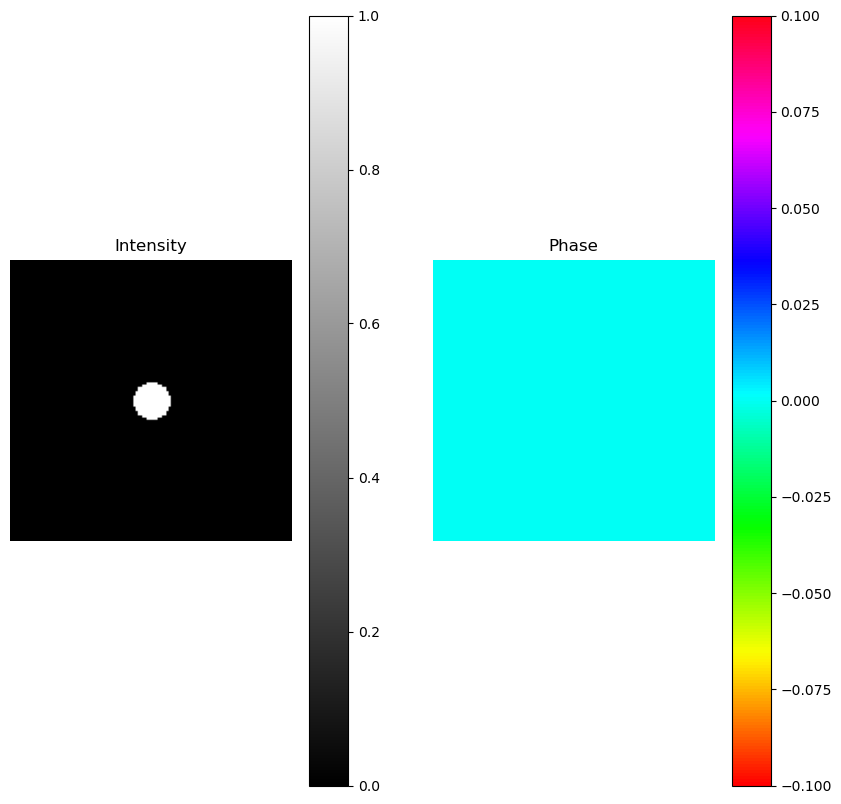

In [7]:
spotty = pupil_function(r, 0.1*mm)
TotInt(spotty)

Defining multiple spots

[-0.0003038129825687827, 7.958325626503376e-05, 0.0003530536155530756]


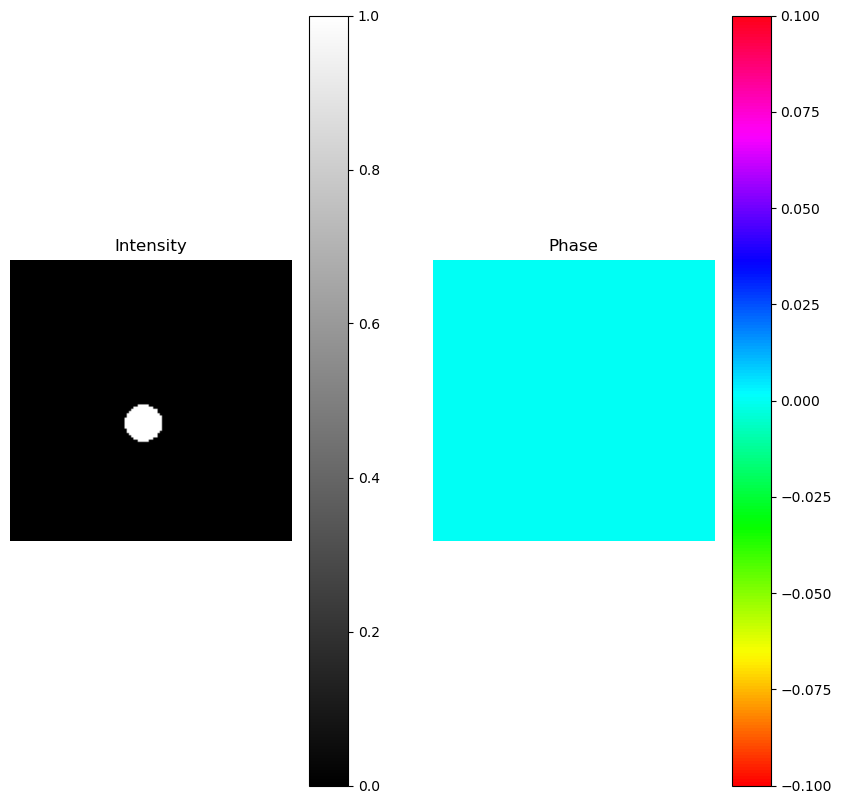

In [8]:
num_of_output_chans = 3

def output_chan(X, Y, rad_spot, maxx, num_of_spots):
    N = len(X)
    spot_loc_x = []
    spot_loc_y = []
    
    for ii in range(num_of_spots):
        spot_loc_x.append(np.random.uniform(-maxx+rad_spot,maxx-rad_spot))
        spot_loc_y.append(np.random.uniform(-maxx+rad_spot,maxx-rad_spot))
    
    print(spot_loc_x)
    
    fields = np.empty((num_of_spots, N, N), dtype=np.complex64)
    # Space definition 
    for ii in range(num_of_spots):
        X=np.linspace(-maxx,maxx,N) + spot_loc_x[ii]
        Y=np.linspace(-maxx,maxx,N) + spot_loc_y[ii]
        h=np.abs(X[1]-X[2]) # Step size
        xx,yy=np.meshgrid(X,Y)
        r, phi= cart2pol(xx,yy)
        
        fields[ii] = pupil_function(r, rad_spot)
    
    return fields, spot_loc_x, spot_loc_y # In principle, it suffices to return fields. 

output_chans, spot_loc_x, spot_loc_y = output_chan(X,Y,0.2*mm,maxx,num_of_output_chans)
TotInt(output_chans[1])

Generating the LG beam 

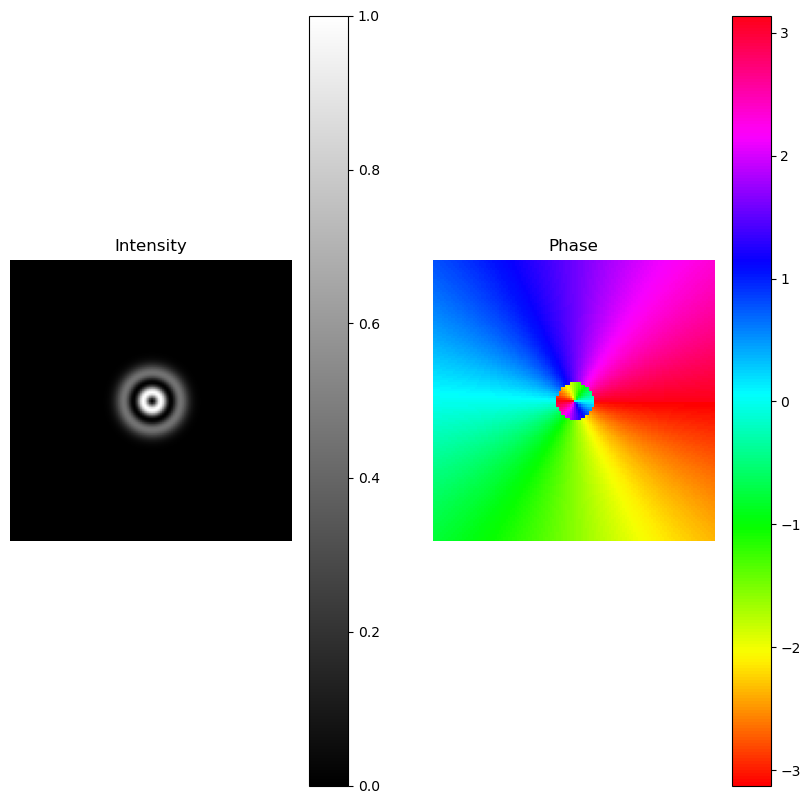

In [9]:
# Generating an LG mode as a test
field = LG(r, phi, 1, 1, 0.1*mm,h,0,k)
field = field / np.max(np.abs(field))
TotInt(field)

Now we propagate the beam towards the fourier length of the lens. Note that we are using Fraunhofer diffraction as we don't have to sample nearly as much. The solution of a beam propagating through a lens also comes out directly w/ z= the focal length of the lens. Here, we assume that the beam is in the back fourier plane. 

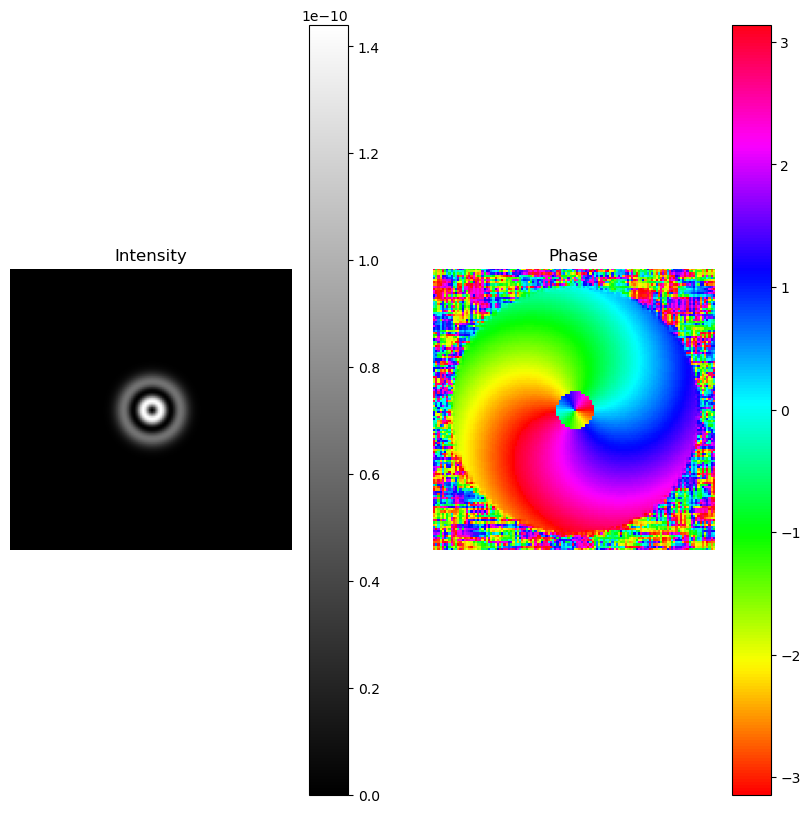

In [10]:
temp_1 = field
prop_dist = 10*cm

# Propagate the lens field to the focal plain of the lens

field_lens,_ = propFF(temp_1, maxx, la, prop_dist)

field_lens = field_lens/np.max(np.abs(field_lens))

# Propagate again immediately before the second lens

field_lens_2 = propFF(field_lens, maxx, la, prop_dist, isInverse=True)[0]

TotInt(field_lens_2)

To verify that what we see adds up, let's actually just compute the phase of the (inverse) fourier transform

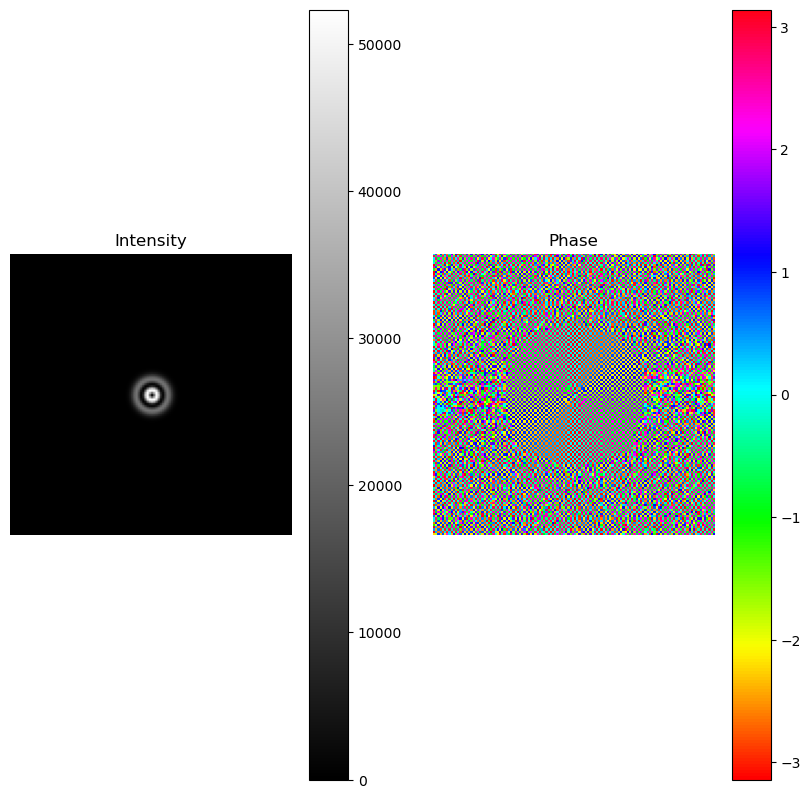

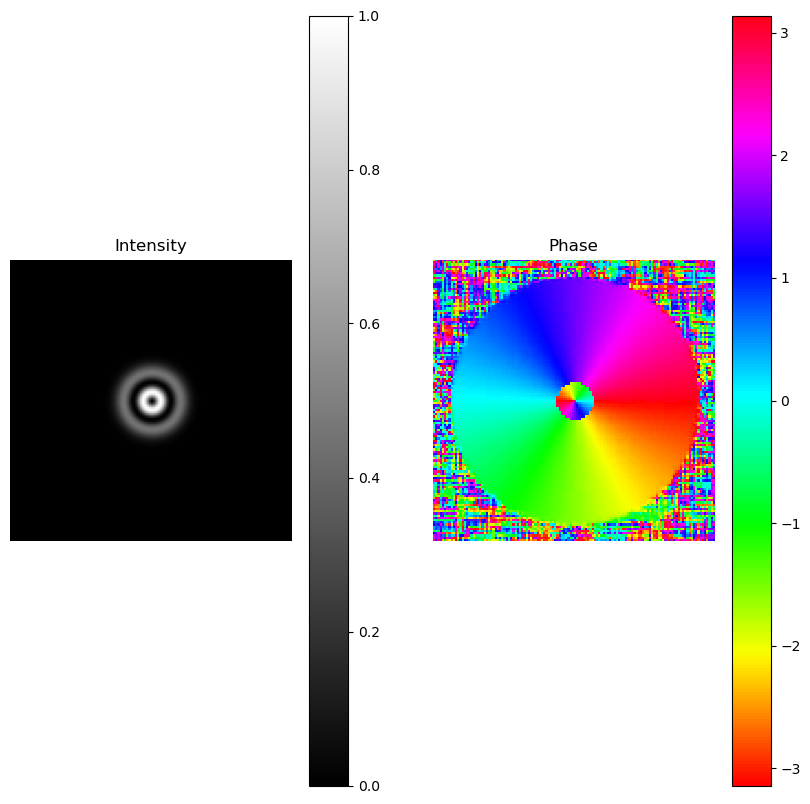

In [11]:
fourField = fftshift(fft2(temp_1))
invFourField = ifft2(ifftshift(fourField))
TotInt(fourField)
TotInt(invFourField)

# Computing the Sorting Probability

We'll need to define the fitness function, which is the sorting performance. For testing purposes, let's define a field having a gaussian beam at one of the three output_channels

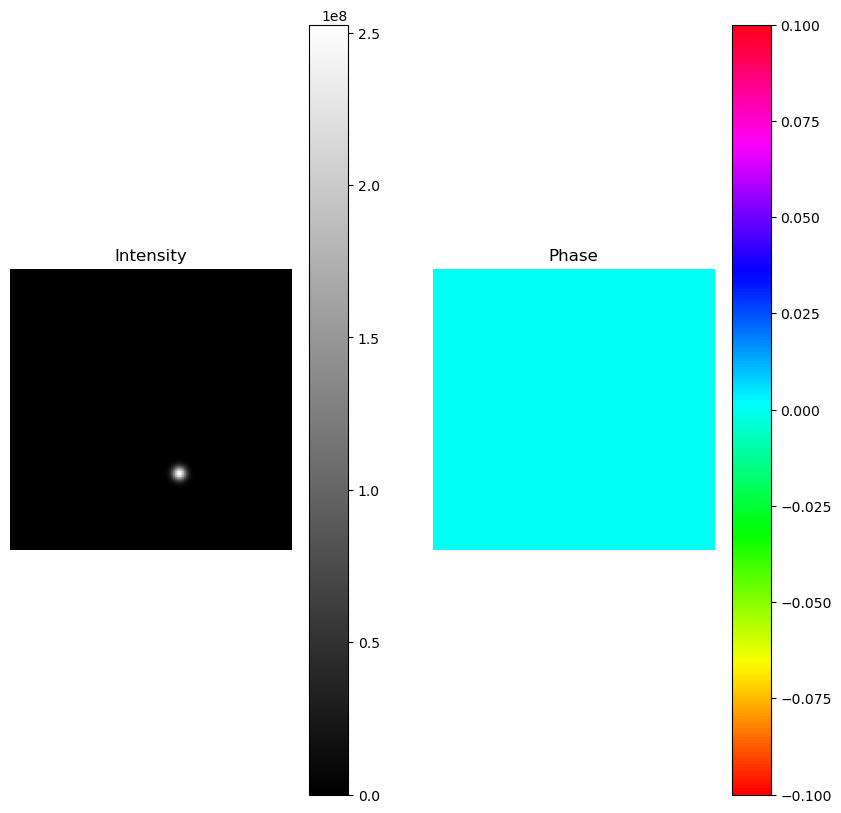

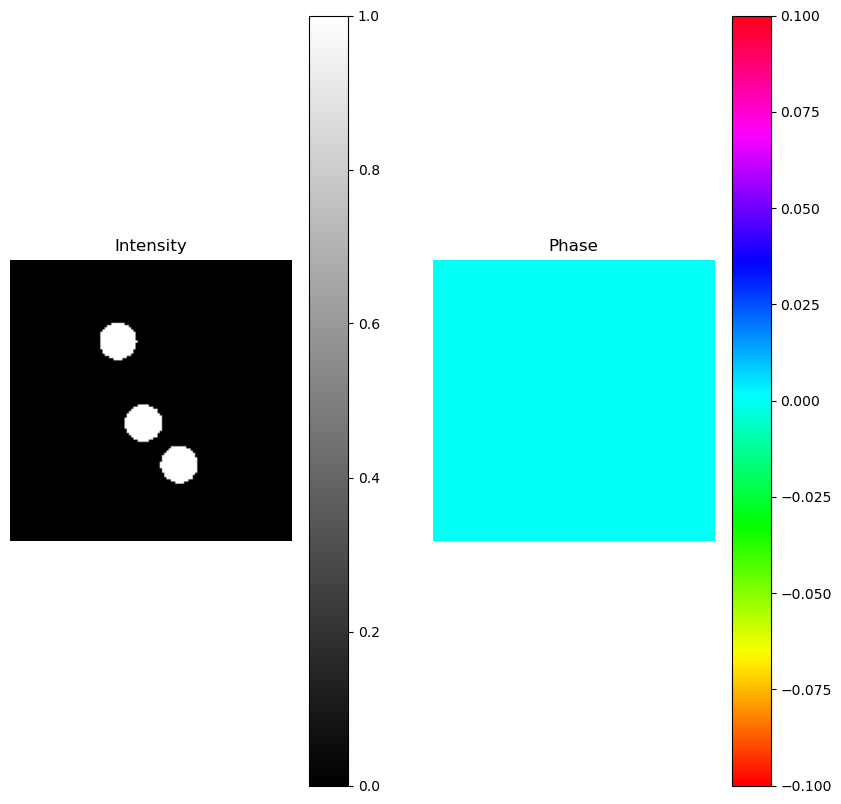

In [12]:
X_gauss=np.linspace(-maxx,maxx,N) + spot_loc_x[0]
Y_gauss=np.linspace(-maxx,maxx,N) + spot_loc_y[0]

h_gauss=np.abs(X[1]-X[2]) # Step size
xx_gauss,yy_gauss=np.meshgrid(X_gauss,Y_gauss)
r_gauss, phi_gauss= cart2pol(xx_gauss,yy_gauss)

# plotting the gaussian field 
gauss_field = LG(r_gauss, phi_gauss, 0, 0, 0.1*mm,h,0,k)
TotInt(gauss_field)
TotInt(np.sum(output_chans, axis=0))

We now compute the sorting performance. This can be done by taking the incident field and convolving it with the pupil array. 

In [13]:
# To normalize, we define the maximum sorting performance, which is the sum of intensities of each output channel

# max_output_intensity = np.sum(output_chans)

# plt.imshow(output_chans[0])

sorting_performance = 0 
ii = 0 # This defines mode n

# Define full set of indices, as you would summing through a for loop

full_index = np.arange(len(output_chans))   

# Delete ii from the list of full_index, creating a new temporary array
temp_index = np.delete(full_index, ii)
# Sum up the "incorrect" channels 
incorrect_chans = 0
for ind in temp_index:
    field_in_pupil = gauss_field*output_chans[ind]
    incorrect_chans += np.abs(field_in_pupil)**2
# Now, evaluate the sorting performance 
sorting_performance += np.abs(gauss_field*output_chans[ii])**2 - incorrect_chans 

# Genetic Algorithm

Let's consider an l=1 LG beam

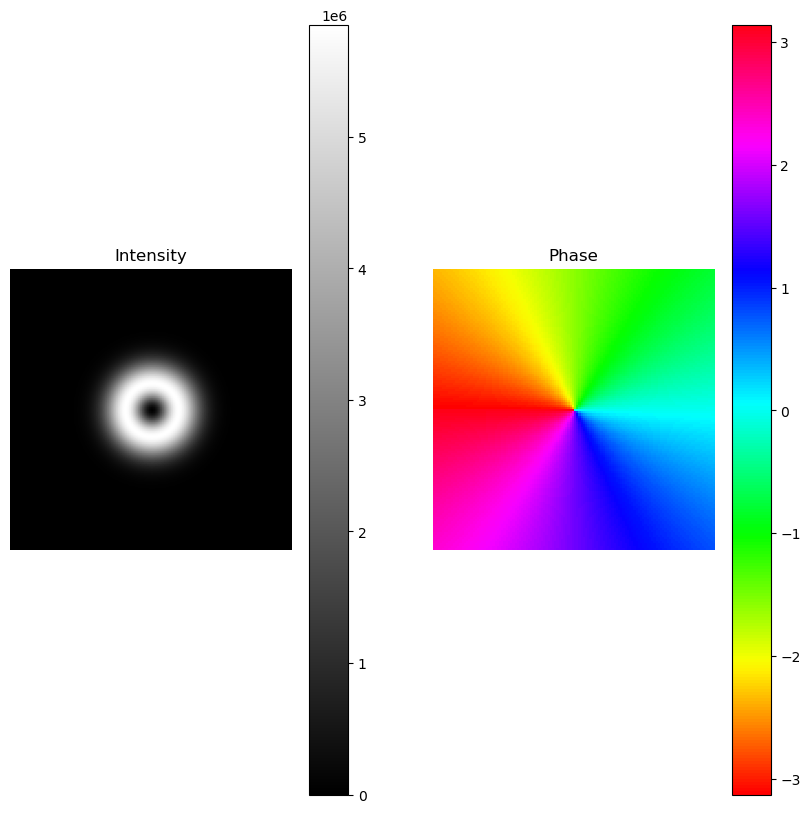

In [14]:
field = LG(r, phi, 1, 0, 0.2*mm,h,0,k)
TotInt(field)

We ... flatten them???

In [15]:
random_phase_modulation_1 = np.random.uniform(-np.pi, np.pi, size=(N,N))
random_phase_modulation_2 = np.random.uniform(-np.pi, np.pi, size=(N,N))

flattened_phase_1 = random_phase_modulation_1.flatten()
flattened_phase_2 = random_phase_modulation_2.flatten()


Define the fitness function. This will be the sorting performance function that we computed earlier

In [16]:
fourier_lens = 10*cm 

# Compute output channels

num_of_output_chans = 2

output_chans, _, _ = output_chan(X,Y,0.2*mm,maxx,num_of_output_chans)

def fitness_func(ga_instance, solution, solution_idx):
    
    # Create the phase map by reshaping the solution array
    
    reshape_phase_1 = np.reshape(a=solution[0:N**2], newshape = (N,N))
    reshape_phase_2 = np.reshape(a=solution[N**2:2*N**2], newshape=(N,N))
    phase_map_1 = np.exp(1j*reshape_phase_1)
    phase_map_2 = np.exp(1j*reshape_phase_2)
    
    # modulate the field by the first phase map 
    
    field_mod_1 = field*phase_map_1
    
    # let's simulate the propagation of the lens

    field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
    
    # modulate the field by the second phase map 
    
    field_mod_2 = field_lens*phase_map_2
    
    # simulate the lens field again. This is the final field. 
    
    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
    
    # compute the field intensity 
    
    final_field_int = np.abs(field_lens_2)**2
    
    # Now, this is the fitness parameter 
    
    sorting_performance = 0 
    
    ii = 0 # This defines mode n

    # Define full set of indices, as you would summing through a for loop

    full_index = np.arange(len(output_chans))   

    # Delete ii from the list of full_index, creating a new temporary array
    
    temp_index = np.delete(full_index, ii)
    
    # Sum up the "incorrect" channels 
    
    incorrect_chans = 0
    
    for ind in temp_index:
        field_in_pupil = final_field_int*output_chans[ind]
        incorrect_chans += np.abs(field_in_pupil)**2
        
    # Now, evaluate the sorting performance 
    
    correct_chans = np.abs(gauss_field*output_chans[ii])**2
    
    sorting_performance += correct_chans - incorrect_chans 
    
    # Compute the normalized sorting probability .. maybe? 
    '''
    full_sorting_const =  correct_chans + incorrect_chans 
    
    print(full_sorting_const)
    
    norm_sorting_prob = correct_chans / (full_sorting_const + 1e-9)

    # Return the mean of the sorting performance 
    
    print(norm_sorting_prob)
    
    print(np.mean(norm_sorting_prob))
    '''
    
    return np.abs(np.mean(sorting_performance))
    


[0.00015885416328057368, 0.0005548461002268042]


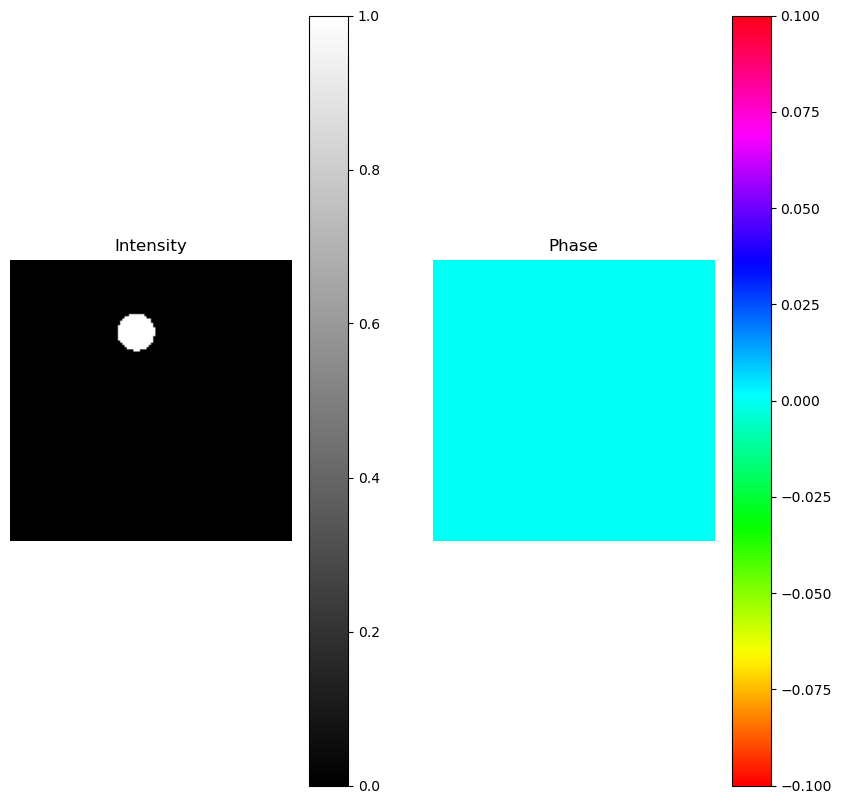

In [36]:
TotInt(output_chans[0])

Parameters for the genetic algorithm. For ease, we store them in a yaml file. 

In [19]:
import pygad
import yaml 
from yaml import Loader 

num_generations = 100000
num_parents_mating =  2

fitness_function = fitness_func 

sol_per_pop = 10 # number of parents in the population?? 
num_genes = num_of_output_chans*len(flattened_phase_1) # This would refer to the number of parameters in our DNA

# Lower and upper-bound ranges of the parameterization. 

init_range_low = -np.pi
init_range_high = np.pi

parent_selection_type = "rank"
#K_tournament = 5 # number of contestants, essentially
#keep_elitism  = 1

crossover_type = "single_point"

mutation_type = "random"
mutation_percent_genes = 10 # probability of mutation 

# This function keeps track of the generation number + best fitness

def on_gen(ga_instance):
    print("Generation : ", ga_instance.generations_completed)
    print("Fitness of the best solution :", ga_instance.best_solution()[1])


Create the GA instance

In [21]:
ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       fitness_func=fitness_function,
                       sol_per_pop=sol_per_pop,
                       num_genes=num_genes,
                       init_range_low=init_range_low,
                       init_range_high=init_range_high,
                       parent_selection_type=parent_selection_type,
                       crossover_type=crossover_type,
                       mutation_type=mutation_type,
                       mutation_percent_genes=mutation_percent_genes,
                       on_generation=on_gen)

Now run the GA

In [60]:
import matplotlib.pyplot as plt

ga_instance.run()
ga_instance.plot_fitness()
plt.savefig('plots/figgy.png')

Generation :  48522
Fitness of the best solution : 58085668.88856911
Generation :  48523
Fitness of the best solution : 58085668.88856911
Generation :  48524
Fitness of the best solution : 58085668.88856911
Generation :  48525
Fitness of the best solution : 58085668.88856911
Generation :  48526
Fitness of the best solution : 58085668.88856911
Generation :  48527
Fitness of the best solution : 58085668.88856911
Generation :  48528
Fitness of the best solution : 58085668.88856911
Generation :  48529
Fitness of the best solution : 58085668.88856911
Generation :  48530
Fitness of the best solution : 58085668.88856911
Generation :  48531
Fitness of the best solution : 58085668.88856911
Generation :  48532
Fitness of the best solution : 58085668.88856911
Generation :  48533
Fitness of the best solution : 58085668.88856911
Generation :  48534
Fitness of the best solution : 58085668.88856911
Generation :  48535
Fitness of the best solution : 58085668.88856911
Generation :  48536
Fitness of the

Generation :  48641
Fitness of the best solution : 58085668.88856911
Generation :  48642
Fitness of the best solution : 58085668.88856911
Generation :  48643
Fitness of the best solution : 58085668.88856911
Generation :  48644
Fitness of the best solution : 58085668.88856911
Generation :  48645
Fitness of the best solution : 58085668.88856911
Generation :  48646
Fitness of the best solution : 58085668.88856911
Generation :  48647
Fitness of the best solution : 58085668.88856911
Generation :  48648
Fitness of the best solution : 58085668.88856911
Generation :  48649
Fitness of the best solution : 58085668.88856911
Generation :  48650
Fitness of the best solution : 58085668.88856911
Generation :  48651
Fitness of the best solution : 58085668.88856911
Generation :  48652
Fitness of the best solution : 58085668.88856911
Generation :  48653
Fitness of the best solution : 58085668.88856911
Generation :  48654
Fitness of the best solution : 58085668.88856911
Generation :  48655
Fitness of the

Generation :  48760
Fitness of the best solution : 58085668.88856911
Generation :  48761
Fitness of the best solution : 58085668.88856911
Generation :  48762
Fitness of the best solution : 58085668.88856911
Generation :  48763
Fitness of the best solution : 58085668.88856911
Generation :  48764
Fitness of the best solution : 58085668.88856911
Generation :  48765
Fitness of the best solution : 58085668.88856911
Generation :  48766
Fitness of the best solution : 58085668.88856911
Generation :  48767
Fitness of the best solution : 58085668.88856911
Generation :  48768
Fitness of the best solution : 58085668.88856911
Generation :  48769
Fitness of the best solution : 58085668.88856911
Generation :  48770
Fitness of the best solution : 58085668.88856911
Generation :  48771
Fitness of the best solution : 58085668.88856911
Generation :  48772
Fitness of the best solution : 58085668.88856911
Generation :  48773
Fitness of the best solution : 58085668.88856911
Generation :  48774
Fitness of the

Generation :  48879
Fitness of the best solution : 58085668.88856911
Generation :  48880
Fitness of the best solution : 58085668.88856911
Generation :  48881
Fitness of the best solution : 58085668.88856911
Generation :  48882
Fitness of the best solution : 58085668.88856911
Generation :  48883
Fitness of the best solution : 58085668.88856911
Generation :  48884
Fitness of the best solution : 58085668.88856911
Generation :  48885
Fitness of the best solution : 58085668.88856911
Generation :  48886
Fitness of the best solution : 58085668.88856911
Generation :  48887
Fitness of the best solution : 58085668.88856911
Generation :  48888
Fitness of the best solution : 58085668.88856911
Generation :  48889
Fitness of the best solution : 58085668.88856911
Generation :  48890
Fitness of the best solution : 58085668.88856911
Generation :  48891
Fitness of the best solution : 58085668.88856911
Generation :  48892
Fitness of the best solution : 58085668.88856911
Generation :  48893
Fitness of the

Generation :  48998
Fitness of the best solution : 58443735.33339842
Generation :  48999
Fitness of the best solution : 58443735.33339842
Generation :  49000
Fitness of the best solution : 58443735.33339842
Generation :  49001
Fitness of the best solution : 58443735.33339842
Generation :  49002
Fitness of the best solution : 58443735.33339842
Generation :  49003
Fitness of the best solution : 58443735.33339842
Generation :  49004
Fitness of the best solution : 58443735.33339842
Generation :  49005
Fitness of the best solution : 58443735.33339842
Generation :  49006
Fitness of the best solution : 58443735.33339842
Generation :  49007
Fitness of the best solution : 58443735.33339842
Generation :  49008
Fitness of the best solution : 58443735.33339842
Generation :  49009
Fitness of the best solution : 58443735.33339842
Generation :  49010
Fitness of the best solution : 58443735.33339842
Generation :  49011
Fitness of the best solution : 58443735.33339842
Generation :  49012
Fitness of the

...

Generation :  78711
Fitness of the best solution : 73708377.15669186
Generation :  78712
Fitness of the best solution : 73708377.15669186
Generation :  78713
Fitness of the best solution : 73708377.15669186
Generation :  78714
Fitness of the best solution : 73708377.15669186
Generation :  78715
Fitness of the best solution : 73708377.15669186
Generation :  78716
Fitness of the best solution : 73708377.15669186
Generation :  78717
Fitness of the best solution : 73708377.15669186
Generation :  78718
Fitness of the best solution : 73708377.15669186
Generation :  78719
Fitness of the best solution : 73708377.15669186
Generation :  78720
Fitness of the best solution : 73708377.15669186
Generation :  78721
Fitness of the best solution : 73708377.15669186
Generation :  78722
Fitness of the best solution : 73708377.15669186
Generation :  78723
Fitness of the best solution : 73708377.15669186
Generation :  78724
Fitness of the best solution : 73708377.15669186
Generation :  78725
Fitness of the

Generation :  78830
Fitness of the best solution : 73708377.15669186
Generation :  78831
Fitness of the best solution : 73708377.15669186
Generation :  78832
Fitness of the best solution : 73708377.15669186
Generation :  78833
Fitness of the best solution : 73708377.15669186
Generation :  78834
Fitness of the best solution : 73708377.15669186
Generation :  78835
Fitness of the best solution : 73708377.15669186
Generation :  78836
Fitness of the best solution : 73708377.15669186
Generation :  78837
Fitness of the best solution : 73708377.15669186
Generation :  78838
Fitness of the best solution : 73708377.15669186
Generation :  78839
Fitness of the best solution : 73708377.15669186
Generation :  78840
Fitness of the best solution : 73708377.15669186
Generation :  78841
Fitness of the best solution : 73708377.15669186
Generation :  78842
Fitness of the best solution : 73708377.15669186
Generation :  78843
Fitness of the best solution : 73708377.15669186
Generation :  78844
Fitness of the

Generation :  78949
Fitness of the best solution : 73708377.15669186
Generation :  78950
Fitness of the best solution : 73708377.15669186
Generation :  78951
Fitness of the best solution : 73708377.15669186
Generation :  78952
Fitness of the best solution : 73708377.15669186
Generation :  78953
Fitness of the best solution : 73708377.15669186
Generation :  78954
Fitness of the best solution : 73708377.15669186
Generation :  78955
Fitness of the best solution : 73708377.15669186
Generation :  78956
Fitness of the best solution : 73708377.15669186
Generation :  78957
Fitness of the best solution : 73708377.15669186
Generation :  78958
Fitness of the best solution : 73708377.15669186
Generation :  78959
Fitness of the best solution : 73708377.15669186
Generation :  78960
Fitness of the best solution : 73708377.15669186
Generation :  78961
Fitness of the best solution : 73708377.15669186
Generation :  78962
Fitness of the best solution : 73708377.15669186
Generation :  78963
Fitness of the

Generation :  79068
Fitness of the best solution : 73708377.15669186
Generation :  79069
Fitness of the best solution : 73708377.15669186
Generation :  79070
Fitness of the best solution : 73708377.15669186
Generation :  79071
Fitness of the best solution : 73708377.15669186
Generation :  79072
Fitness of the best solution : 73708377.15669186
Generation :  79073
Fitness of the best solution : 73708377.15669186
Generation :  79074
Fitness of the best solution : 73708377.15669186
Generation :  79075
Fitness of the best solution : 73708377.15669186
Generation :  79076
Fitness of the best solution : 73708377.15669186
Generation :  79077
Fitness of the best solution : 73708377.15669186
Generation :  79078
Fitness of the best solution : 73708377.15669186
Generation :  79079
Fitness of the best solution : 73708377.15669186
Generation :  79080
Fitness of the best solution : 73708377.15669186
Generation :  79081
Fitness of the best solution : 73708377.15669186
Generation :  79082
Fitness of the

KeyboardInterrupt: 

# Analyzing the Solution of the GA 

extract the solution, and reshape it in an interpretable form 

In [61]:
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print("Parameters of the best solution : {solution}".format(solution=solution))
print("Fitness value of the best solution = {solution_fitness}".format(solution_fitness=solution_fitness))


Parameters of the best solution : [-10.88591262   9.22469061  -7.97325995 ...   2.90871584   3.60641291
   1.50432222]
Fitness value of the best solution = 73708377.15669186


Save the genetic instance

In [62]:
instance_name = 'first_trial'
ga_instance.save(filename=f'genetic_instances/{instance_name}')

Let's analyze what we've made

In [63]:
# Create the phase map by reshaping the solution array

reshape_phase_1 = np.reshape(a=solution[0:N**2], newshape = (N,N))
reshape_phase_2 = np.reshape(a=solution[N**2:2*N**2], newshape=(N,N))
phase_map_1 = np.exp(1j*reshape_phase_1)
phase_map_2 = np.exp(1j*reshape_phase_2)

# modulate the field by the first phase map 

field_mod_1 = field*phase_map_1

# let's simulate the propagation of the lens

field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)

# modulate the field by the second phase map 

field_mod_2 = field_lens*phase_map_2

# simulate the lens field again. This is the final field. 

field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)

# compute the field intensity 

final_field_int = np.abs(field_lens_2)**2

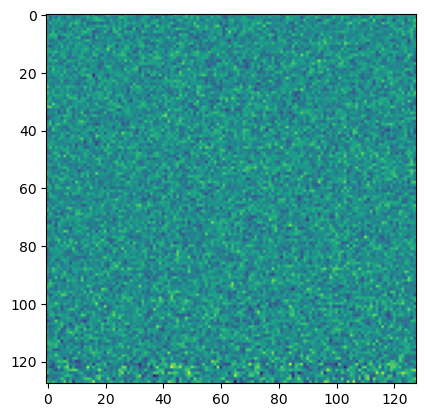

In [67]:
plt.imshow(reshape_phase_2)